# 박스 시퀀스 vs 팔레트 용량 분석

**목적** — `templete code/box_sequence` 의 입력 박스들을 우리 팔레트(bin)에 **애초에 다 담을 수 없다**는 점을 정량적으로 확인한다.

핵심 질문:
1. 박스 전체 부피의 합이 팔레트 부피를 얼마나 초과하는가?
2. 부피가 100%로 완벽히 채워진다고 가정해도(이론적 상한) 몇 번째 박스에서 용량을 넘어서는가?
3. 현실적인 패킹 효율을 감안하면 실제로 몇 개나 적재 가능한가?
4. 박스 크기·질량 분포는 어떤가?

> 분석 전용 노트북이다. 제출 코드와 무관하므로 pandas/matplotlib 등을 자유롭게 사용한다.

In [ ]:
import platform
import json
import glob
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
def set_korean_font():
    system = platform.system()
    if system == 'Windows':
        plt.rcParams['font.family'] = 'Malgun Gothic'
    elif system == 'Darwin':  # macOS
        plt.rcParams['font.family'] = 'AppleGothic'
    else:  # Linux (서버 환경)
        # 나눔 폰트 설치 후 사용
        # sudo apt-get install fonts-nanum
        import subprocess
        subprocess.run(['apt-get', 'install', '-y', 'fonts-nanum'],
                      capture_output=True)
        fm._load_fontmanager(try_read_cache=False)
        font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
        font_prop = fm.FontProperties(fname=font_path)
        plt.rcParams['font.family'] = font_prop.get_name()

    plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

set_korean_font()

In [ ]:
# ── 설정 ───────────────────────────────────────────────
# 팔레트(bin) 크기 (m) — config/algorithm_config.yaml 및 과제 규격 기준
#   가로(length, X) 1.2 / 세로(width, Y) 1.0 / 최대높이(height, Z) 1.25
PALLET = {"length": 1.2, "width": 1.0, "height": 1.25}
PALLET_VOLUME = PALLET["length"] * PALLET["width"] * PALLET["height"]  # 1.5 m^3

# box_sequence 폴더 경로 
BOX_DIR = '../box_sequence'

print(f"팔레트 크기      : {PALLET['length']} x {PALLET['width']} x {PALLET['height']} m")
print(f"팔레트 부피      : {PALLET_VOLUME:.4f} m^3")
print(f"box_sequence 경로: {BOX_DIR}")

팔레트 크기      : 1.2 x 1.0 x 1.25 m
팔레트 부피      : 1.5000 m^3
box_sequence 경로: ../box_sequence


## 1. 데이터 로드

`box_sequence` 파일은 한 줄에 박스 하나씩인 **JSONL** 형식이다(드물게 JSON 배열일 수 있어 둘 다 처리). 각 박스는 `step, id, size=[L, W, H], mass` 등을 가진다.

In [8]:
def load_boxes(path):
    """JSONL 또는 JSON 배열 파일을 박스 리스트로 로드."""
    with open(path, "r", encoding="utf-8") as f:
        text = f.read().strip()
    if not text:
        return []
    if text[0] == "[":
        return json.loads(text)
    return [json.loads(line) for line in text.splitlines() if line.strip()]


def box_volume(b):
    L, W, H = b["size"]
    return float(L) * float(W) * float(H)


files = sorted(glob.glob(os.path.join(BOX_DIR, "*.json")))
datasets = {os.path.basename(f): load_boxes(f) for f in files}

for name, boxes in datasets.items():
    print(f"{name:24s}  박스 수 = {len(boxes)}")

# 첫 파일 미리보기
first = next(iter(datasets))
pd.DataFrame(datasets[first]).head()

box_sequence_0.json       박스 수 = 250
box_sequence_1.json       박스 수 = 250


,step,id,type,type_name,size,mass
0,0,0,3,4,"[0.31, 0.233, 0.21]",4.0
1,1,1,0,1,"[0.195, 0.178, 0.134]",0.5
2,2,2,1,2,"[0.245, 0.178, 0.14]",1.0
3,3,3,1,2,"[0.245, 0.178, 0.14]",1.0
4,4,4,3,4,"[0.31, 0.233, 0.21]",4.0


## 2. 용량 대비 전체 부피

각 데이터셋의 박스 부피 총합을 팔레트 부피(1.5 m³)와 비교한다. 비율이 1을 넘으면 **물리적으로 전부 담는 것이 불가능**하다는 뜻이다.

In [14]:
rows = []
for name, boxes in datasets.items():
    vols = np.array([box_volume(b) for b in boxes])
    total = vols.sum()
    rows.append({
        "dataset": name,
        "박스수": len(boxes),
        "총부피(m^3)": round(total, 4),
        "팔레트부피(m^3)": round(PALLET_VOLUME, 4),
        "초과배율": round(total / PALLET_VOLUME, 3),
        "평균박스부피(m^3)": round(vols.mean(), 5),
    })

summary = pd.DataFrame(rows)
display(summary)

print()
for r in rows:
    print(f"[{r['dataset']}] 총 부피가 팔레트의 {r['초과배율']}배 "
          f"→ 부피만 봐도 전부 적재 불가능 (이상적으로 채워도 약 {round(1/r['초과배율']*100,1)}%만 수용)")

,dataset,박스수,총부피(m^3),팔레트부피(m^3),초과배율,평균박스부피(m^3)
0,box_sequence_0.json,250,2.7930,1.5,1.862,0.01117
1,box_sequence_1.json,250,2.9327,1.5,1.955,0.01173



[box_sequence_0.json] 총 부피가 팔레트의 1.862배 → 부피만 봐도 전부 적재 불가능 (이상적으로 채워도 약 53.7%만 수용)
[box_sequence_1.json] 총 부피가 팔레트의 1.955배 → 부피만 봐도 전부 적재 불가능 (이상적으로 채워도 약 51.2%만 수용)


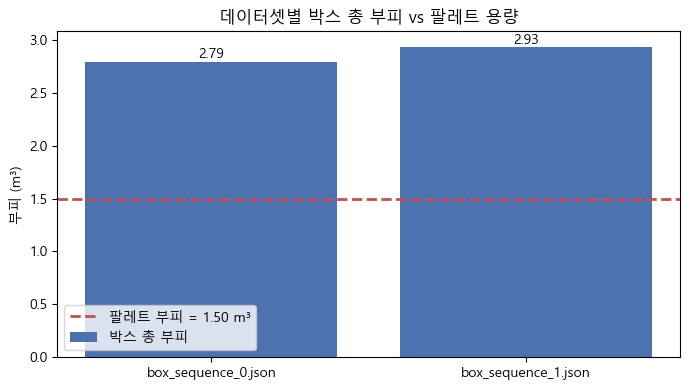

In [15]:
# 막대그래프: 데이터셋별 총 박스 부피 vs 팔레트 부피
fig, ax = plt.subplots(figsize=(7, 4))
names = [r["dataset"] for r in rows]
totals = [r["총부피(m^3)"] for r in rows]
ax.bar(names, totals, color="#4C72B0", label="박스 총 부피")
ax.axhline(PALLET_VOLUME, color="#C44E52", linestyle="--", linewidth=2,
           label=f"팔레트 부피 = {PALLET_VOLUME:.2f} m³")
ax.set_ylabel("부피 (m³)")
ax.set_title("데이터셋별 박스 총 부피 vs 팔레트 용량")
ax.legend()
for i, v in enumerate(totals):
    ax.text(i, v + 0.03, f"{v:.2f}", ha="center")
plt.tight_layout()
plt.show()

In [21]:
def load(p):
    t = open(p, encoding="utf-8").read().strip()
    return json.loads(t) if t[0] == "[" else [json.loads(l) for l in t.splitlines() if l.strip()]

BOX_DIR = "../box_sequence"   # 필요시 경로 수정
boxes = [b for f in sorted(glob.glob(os.path.join(BOX_DIR, "*.json"))) for b in load(f)]

df = pd.DataFrame(boxes)
df[["L", "W", "H"]] = pd.DataFrame(df["size"].tolist(), index=df.index)
df["vol"] = df["L"] * df["W"] * df["H"]
df["density"] = df["mass"] / df["vol"]

# (1) 타입별 (L,W,H,mass)가 정말 고정인지 검증: 각 치수의 min==max 이면 고정
chk = df.groupby("type")[["L", "W", "H", "mass"]].agg(["min", "max"])
is_fixed = (chk.xs("min", axis=1, level=1) == chk.xs("max", axis=1, level=1)).all().all()
print("타입별 (L,W,H,mass) 완전 고정 여부:", is_fixed)

# (2) 5개 규격(SKU) 요약 표
spec = (df.groupby(["type", "type_name"])
          .agg(L=("L", "first"), W=("W", "first"), H=("H", "first"),
               mass=("mass", "first"), count=("id", "size"))
          .reset_index())
spec["vol"]      = (spec.L * spec.W * spec.H).round(5)
spec["density"]  = (spec.mass / spec.vol).round(1)
spec["ratio_LW"] = (spec.L / spec.W).round(2)   # 밑면 가로세로비
spec["count_%"]  = (spec["count"] / len(df) * 100).round(1)
display(spec)

타입별 (L,W,H,mass) 완전 고정 여부: True


,type,type_name,L,W,H,mass,count,vol,density,ratio_LW,count_%
0,0,1,0.195,0.178,0.134,0.5,89,0.00465,107.5,1.10,17.8
1,1,2,0.245,0.178,0.140,1.0,110,0.00611,163.7,1.38,22.0
2,2,3,0.245,0.220,0.158,2.0,99,0.00852,234.7,1.11,19.8
3,3,4,0.310,0.233,0.210,4.0,95,0.01517,263.7,1.33,19.0
4,4,5,0.315,0.272,0.257,6.0,107,0.02202,272.5,1.16,21.4


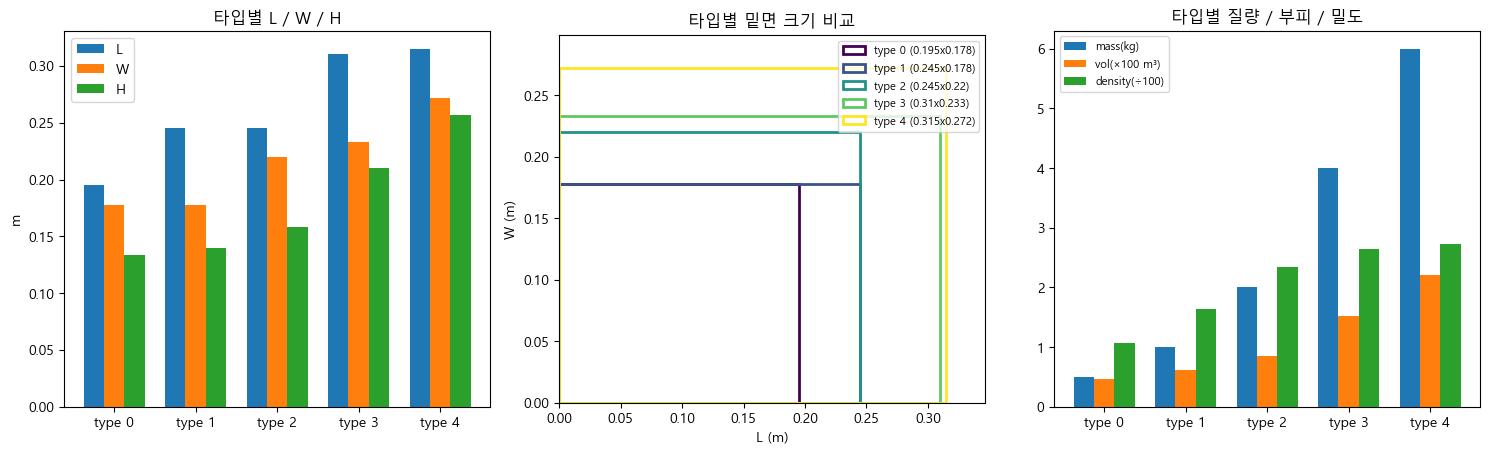

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# 1) L, W, H 그룹 막대
x = np.arange(len(spec)); w = 0.25
axes[0].bar(x - w, spec.L, w, label="L")
axes[0].bar(x,     spec.W, w, label="W")
axes[0].bar(x + w, spec.H, w, label="H")
axes[0].set_xticks(x); axes[0].set_xticklabels([f"type {t}" for t in spec.type])
axes[0].set_ylabel("m"); axes[0].set_title("타입별 L / W / H"); axes[0].legend()

# 2) 밑면(footprint) 윤곽 — 원점 정렬해서 크기 비교
colors = plt.cm.viridis(np.linspace(0, 1, len(spec)))
for (_, r), c in zip(spec.iterrows(), colors):
    axes[1].add_patch(plt.Rectangle((0, 0), r.L, r.W, fill=False, edgecolor=c, lw=2,
                                     label=f"type {r.type} ({r.L}x{r.W})"))
axes[1].set_xlim(0, spec.L.max() * 1.1); axes[1].set_ylim(0, spec.W.max() * 1.1)
axes[1].set_aspect("equal"); axes[1].set_xlabel("L (m)"); axes[1].set_ylabel("W (m)")
axes[1].set_title("타입별 밑면 크기 비교"); axes[1].legend(fontsize=8)

# 3) 질량 / 부피 / 밀도
axes[2].bar(x - w, spec.mass, w, label="mass(kg)")
axes[2].bar(x,     spec.vol * 100, w, label="vol(×100 m³)")
axes[2].bar(x + w, spec.density / 100, w, label="density(÷100)")
axes[2].set_xticks(x); axes[2].set_xticklabels([f"type {t}" for t in spec.type])
axes[2].set_title("타입별 질량 / 부피 / 밀도"); axes[2].legend(fontsize=8)

plt.tight_layout(); plt.show()

## 결론

- 데이터셋의 박스 총 부피는 팔레트 부피(1.5 m³)의 **약 1.8~1.9배**라서, 부피만 따져도 전부 적재하는 것은 불가능하다.
- 틈 없이 100%로 채운다는 비현실적 가정에서도 **절반 안팎**의 박스만 들어가고, 현실적 패킹 효율(60~75%)을 적용하면 **그보다 더 적다.**
- 따라서 과제의 본질은 "모든 박스 적재"가 아니라, **버퍼 윈도우 안에서 어떤 박스를 골라 1.5 m³ 한도 안에 안정적으로(붕괴·이탈·높이초과 없이) 채워 적재율을 극대화할지** 선택·배치하는 최적화 문제다.
- 평가셋은 매번 새로 랜덤 생성되므로, 특정 파일이 아니라 위에서 본 **크기·질량 분포 전반에 강건한 전략**을 설계해야 한다.